# DriveSafe AI
Driver Risk Score Analytics System

In [ ]:
print('DriveSafe AI notebook initialized')

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
VISUALS_DIR = PROJECT_ROOT / "visuals"

for folder in [DATA_DIR, MODELS_DIR, REPORTS_DIR, VISUALS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def generate_driver_dataset(n_rows: int = 5000, random_state: int = 42) -> pd.DataFrame:
    local_rng = np.random.default_rng(random_state)

    driver_id = np.arange(100001, 100001 + n_rows)
    age = np.clip(local_rng.normal(39, 11, n_rows), 18, 70).round().astype(int)
    experience_years = np.clip(
        age - 18 - local_rng.normal(1.8, 4.0, n_rows), 0, None
    ).round().astype(int)
    avg_speed = np.clip(local_rng.normal(58, 12, n_rows) + local_rng.normal(0, 4, n_rows), 25, 110)
    harsh_braking = local_rng.poisson(
        lam=np.clip((avg_speed - 40) / 18 + local_rng.normal(0.8, 0.4, n_rows), 0.2, 6)
    )
    sudden_acceleration = local_rng.poisson(
        lam=np.clip((avg_speed - 36) / 20 + local_rng.normal(0.7, 0.4, n_rows), 0.2, 5)
    )
    weekly_driving_hours = np.clip(local_rng.normal(38, 12, n_rows) + 0.22 * experience_years, 5, 85)
    mobile_usage_minutes = np.clip(
        local_rng.gamma(shape=2.2, scale=8.5, size=n_rows) + np.maximum(0, 12 - experience_years * 0.15),
        0,
        130,
    )
    night_driving_hours = np.clip(
        local_rng.normal(3.0, 1.7, n_rows) + np.maximum(0, 28 - experience_years) * 0.03, 0, 12
    )
    fatigue_score = np.clip(
        0.24 * night_driving_hours + 0.014 * weekly_driving_hours + 0.028 * mobile_usage_minutes
        + local_rng.normal(1.8, 1.1, n_rows),
        0,
        10,
    )
    traffic_violations = local_rng.poisson(
        lam=np.clip(0.08 * harsh_braking + 0.1 * sudden_acceleration + 0.05 * night_driving_hours, 0.05, 5)
    )
    seatbelt_compliance = np.clip(
        local_rng.normal(0.93, 0.07, n_rows)
        - 0.0015 * mobile_usage_minutes
        - 0.001 * night_driving_hours
        + 0.001 * experience_years,
        0.35,
        1.0,
    )
    weather_risk = local_rng.choice([1, 2, 3, 4, 5], size=n_rows, p=[0.17, 0.26, 0.28, 0.19, 0.10])
    accident_history = local_rng.poisson(
        lam=np.clip(0.06 * traffic_violations + 0.03 * night_driving_hours + 0.02 * weather_risk, 0.0, 3.0)
    )

    latent_risk = (
        0.30 * (avg_speed - 50) / 10
        + 0.42 * harsh_braking
        + 0.36 * sudden_acceleration
        + 0.06 * mobile_usage_minutes
        + 0.60 * night_driving_hours
        + 0.72 * fatigue_score
        + 0.58 * traffic_violations
        + 2.2 * (1 - seatbelt_compliance)
        + 0.48 * weather_risk
        + 0.05 * weekly_driving_hours
        + 1.05 * accident_history
        - 0.06 * experience_years
        - 0.03 * np.maximum(0, age - 18)
        + local_rng.normal(0, 2.0, n_rows)
    )

    low_cutoff, high_cutoff = np.quantile(latent_risk, [0.56, 0.82])
    driver_risk = np.where(
        latent_risk < low_cutoff,
        "Safe",
        np.where(latent_risk < high_cutoff, "Moderate Risk", "High Risk"),
    )

    df = pd.DataFrame(
        {
            "driver_id": driver_id,
            "age": age,
            "experience_years": experience_years,
            "avg_speed": avg_speed.round(2),
            "harsh_braking": harsh_braking,
            "sudden_acceleration": sudden_acceleration,
            "mobile_usage_minutes": mobile_usage_minutes.round(2),
            "night_driving_hours": night_driving_hours.round(2),
            "fatigue_score": fatigue_score.round(2),
            "traffic_violations": traffic_violations,
            "seatbelt_compliance": seatbelt_compliance.round(3),
            "weather_risk": weather_risk,
            "weekly_driving_hours": weekly_driving_hours.round(2),
            "accident_history": accident_history,
            "driver_risk": driver_risk,
        }
    )

    missing_specs = {
        "mobile_usage_minutes": 0.035,
        "night_driving_hours": 0.03,
        "seatbelt_compliance": 0.025,
        "traffic_violations": 0.02,
        "weather_risk": 0.02,
    }
    for column, fraction in missing_specs.items():
        missing_index = local_rng.choice(df.index, size=int(n_rows * fraction), replace=False)
        df.loc[missing_index, column] = np.nan

    return df


In [2]:
driver_df = generate_driver_dataset()
dataset_path = DATA_DIR / "driver_risk_dataset.csv"
driver_df.to_csv(dataset_path, index=False)

print(f"Saved synthetic dataset to: {dataset_path}")
print(f"Rows: {driver_df.shape[0]}, Columns: {driver_df.shape[1]}")
print(driver_df["driver_risk"].value_counts(normalize=True).sort_index().round(3))
driver_df.head()


Saved synthetic dataset to: d:\Driver Risk Score Analysis\data\driver_risk_dataset.csv
Rows: 5000, Columns: 15
driver_risk
High Risk        0.18
Moderate Risk    0.26
Safe             0.56
Name: proportion, dtype: float64


,driver_id,age,experience_years,avg_speed,harsh_braking,sudden_acceleration,mobile_usage_minutes,night_driving_hours,fatigue_score,traffic_violations,seatbelt_compliance,weather_risk,weekly_driving_hours,accident_history,driver_risk
0,100001,42,23,63.83,1,1,64.84,3.37,4.50,0.0,NaN,2.0,53.59,0,Safe
1,100002,28,9,72.63,5,1,23.14,0.00,3.09,1.0,0.889,4.0,62.82,0,Moderate Risk
2,100003,47,30,43.33,1,1,18.26,2.59,4.72,0.0,0.909,3.0,61.99,1,Safe
3,100004,49,27,56.34,2,2,39.08,1.32,3.71,0.0,0.749,1.0,45.45,0,Safe
4,100005,18,0,69.60,2,2,22.04,3.49,3.57,0.0,0.914,3.0,43.77,1,High Risk


In [3]:
driver_df = pd.read_csv(DATA_DIR / "driver_risk_dataset.csv")
print(f"Loaded dataset shape: {driver_df.shape}")
display(driver_df.head())
display(driver_df.sample(5, random_state=RANDOM_STATE))
print(driver_df.dtypes)
print(driver_df["driver_risk"].value_counts())


Loaded dataset shape: (5000, 15)


,driver_id,age,experience_years,avg_speed,harsh_braking,sudden_acceleration,mobile_usage_minutes,night_driving_hours,fatigue_score,traffic_violations,seatbelt_compliance,weather_risk,weekly_driving_hours,accident_history,driver_risk
0,100001,42,23,63.83,1,1,64.84,3.37,4.50,0.0,NaN,2.0,53.59,0,Safe
1,100002,28,9,72.63,5,1,23.14,0.00,3.09,1.0,0.889,4.0,62.82,0,Moderate Risk
2,100003,47,30,43.33,1,1,18.26,2.59,4.72,0.0,0.909,3.0,61.99,1,Safe
3,100004,49,27,56.34,2,2,39.08,1.32,3.71,0.0,0.749,1.0,45.45,0,Safe
4,100005,18,0,69.60,2,2,22.04,3.49,3.57,0.0,0.914,3.0,43.77,1,High Risk


,driver_id,age,experience_years,avg_speed,harsh_braking,sudden_acceleration,mobile_usage_minutes,night_driving_hours,fatigue_score,traffic_violations,seatbelt_compliance,weather_risk,weekly_driving_hours,accident_history,driver_risk
1501,101502,32,6,69.44,5,0,44.56,NaN,4.46,1.0,0.836,4.0,41.63,0,High Risk
2586,102587,40,17,54.99,2,5,20.61,3.23,4.75,0.0,0.803,3.0,28.25,0,Safe
2653,102654,30,10,65.29,3,2,50.59,4.58,3.76,0.0,0.964,NaN,47.44,0,High Risk
1055,101056,55,33,80.39,2,1,20.77,0.17,2.25,0.0,0.874,2.0,49.83,0,Safe
705,100706,28,7,54.25,0,1,22.75,6.98,3.81,0.0,0.794,1.0,54.99,0,Safe


driver_id                 int64
age                       int64
experience_years          int64
avg_speed               float64
harsh_braking             int64
sudden_acceleration       int64
mobile_usage_minutes    float64
night_driving_hours     float64
fatigue_score           float64
traffic_violations      float64
seatbelt_compliance     float64
weather_risk            float64
weekly_driving_hours    float64
accident_history          int64
driver_risk                 str
dtype: object
driver_risk
Safe             2800
Moderate Risk    1300
High Risk         900
Name: count, dtype: int64


In [4]:
print(f"Dataset shape: {driver_df.shape}")
print("Duplicate rows:", driver_df.duplicated().sum())
print("Target distribution:\n", driver_df["driver_risk"].value_counts())

display(driver_df.describe(include="all").T)


Dataset shape: (5000, 15)
Duplicate rows: 0
Target distribution:
 driver_risk
Safe             2800
Moderate Risk    1300
High Risk         900
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
driver_id,5000.0,NaN,NaN,NaN,102500.5,1443.520003,100001.0,101250.75,102500.5,103750.25,105000.0
age,5000.0,NaN,NaN,NaN,38.9058,10.690041,18.0,31.0,39.0,46.0,70.0
experience_years,5000.0,NaN,NaN,NaN,19.265,11.248897,0.0,11.0,19.0,27.0,63.0
avg_speed,5000.0,NaN,NaN,NaN,58.107864,12.667352,25.0,49.58,57.7,66.4,108.09
harsh_braking,5000.0,NaN,NaN,NaN,1.8552,1.591584,0.0,1.0,2.0,3.0,10.0
sudden_acceleration,5000.0,NaN,NaN,NaN,1.8044,1.542276,0.0,1.0,2.0,3.0,9.0
mobile_usage_minutes,4825.0,NaN,NaN,NaN,27.837302,12.76057,6.47,18.58,25.2,34.37,96.01
night_driving_hours,4850.0,NaN,NaN,NaN,3.338148,1.668604,0.0,2.17,3.33,4.48,9.21
fatigue_score,5000.0,NaN,NaN,NaN,3.947546,1.240466,0.0,3.11,3.91,4.7825,8.7
traffic_violations,4900.0,NaN,NaN,NaN,0.500612,0.744442,0.0,0.0,0.0,1.0,5.0


In [5]:
missing_counts = driver_df.isna().sum().sort_values(ascending=False)
missing_pct = (driver_df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:")
display(missing_summary)


Columns with missing values:


,missing_count,missing_pct
mobile_usage_minutes,175,3.5
night_driving_hours,150,3.0
seatbelt_compliance,125,2.5
traffic_violations,100,2.0
weather_risk,100,2.0


In [6]:
cleaned_df = driver_df.copy()

numeric_columns = cleaned_df.select_dtypes(include=["number"]).columns.tolist()
numeric_columns = [column for column in numeric_columns if column != "driver_id"]

for column in numeric_columns:
    cleaned_df[column] = cleaned_df[column].fillna(cleaned_df[column].median())

cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)
print("Remaining missing values:", cleaned_df.isna().sum().sum())
print("Cleaned shape:", cleaned_df.shape)
display(cleaned_df.head())


Remaining missing values: 0
Cleaned shape: (5000, 15)


,driver_id,age,experience_years,avg_speed,harsh_braking,sudden_acceleration,mobile_usage_minutes,night_driving_hours,fatigue_score,traffic_violations,seatbelt_compliance,weather_risk,weekly_driving_hours,accident_history,driver_risk
0,100001,42,23,63.83,1,1,64.84,3.37,4.50,0.0,0.901,2.0,53.59,0,Safe
1,100002,28,9,72.63,5,1,23.14,0.00,3.09,1.0,0.889,4.0,62.82,0,Moderate Risk
2,100003,47,30,43.33,1,1,18.26,2.59,4.72,0.0,0.909,3.0,61.99,1,Safe
3,100004,49,27,56.34,2,2,39.08,1.32,3.71,0.0,0.749,1.0,45.45,0,Safe
4,100005,18,0,69.60,2,2,22.04,3.49,3.57,0.0,0.914,3.0,43.77,1,High Risk


In [7]:
cleaned_df["driving_discipline_score"] = (
    100
    - 0.5 * np.maximum(cleaned_df["avg_speed"] - 50, 0)
    - 6.5 * cleaned_df["harsh_braking"]
    - 6.0 * cleaned_df["sudden_acceleration"]
    - 0.65 * cleaned_df["mobile_usage_minutes"]
    - 3.0 * cleaned_df["traffic_violations"]
    - 10.0 * (1 - cleaned_df["seatbelt_compliance"])
).clip(0, 100)

print(cleaned_df[["driving_discipline_score"]].describe().round(2))


       driving_discipline_score
count                   5000.00
mean                      51.73
std                       20.18
min                        0.00
25%                       38.67
50%                       54.13
75%                       67.03
max                       93.43


In [8]:
cleaned_df["fatigue_risk_index"] = (
    0.34 * cleaned_df["night_driving_hours"]
    + 0.20 * cleaned_df["fatigue_score"]
    + 0.09 * (cleaned_df["mobile_usage_minutes"] / 10)
    + 0.03 * cleaned_df["weekly_driving_hours"]
    - 0.02 * cleaned_df["experience_years"]
).clip(lower=0)

print(cleaned_df[["fatigue_risk_index"]].describe().round(2))


       fatigue_risk_index
count             5000.00
mean                 3.05
std                  0.84
min                  0.06
25%                  2.48
50%                  3.04
75%                  3.61
max                  5.86


In [9]:
cleaned_df["violation_frequency"] = cleaned_df["traffic_violations"] / (cleaned_df["weekly_driving_hours"] / 10 + 1)

print(cleaned_df[["violation_frequency"]].describe().round(3))


       violation_frequency
count             5000.000
mean                 0.102
std                  0.163
min                  0.000
25%                  0.000
50%                  0.000
75%                  0.187
max                  1.342


In [10]:
cleaned_df["accident_risk_score"] = (
    1.4 * cleaned_df["accident_history"]
    + 0.45 * cleaned_df["violation_frequency"]
    + 0.20 * cleaned_df["weather_risk"]
).clip(lower=0)

print(cleaned_df[["accident_risk_score"]].describe().round(3))


       accident_risk_score
count             5000.000
mean                 0.878
std                  0.691
min                  0.200
25%                  0.400
50%                  0.600
75%                  1.000
max                  5.259


In [11]:
cleaned_df["behavior_risk_score"] = (
    0.35 * (100 - cleaned_df["driving_discipline_score"])
    + 12.0 * cleaned_df["fatigue_risk_index"]
    + 18.0 * cleaned_df["violation_frequency"]
    + 8.0 * cleaned_df["accident_risk_score"]
).clip(0, 100)

print(cleaned_df[["behavior_risk_score"]].describe().round(2))


       behavior_risk_score
count              5000.00
mean                 62.31
std                  15.42
min                  16.94
25%                  51.40
50%                  61.58
75%                  72.44
max                 100.00


In [12]:
eda_df = cleaned_df.copy()
risk_map = {"Safe": 0, "Moderate Risk": 1, "High Risk": 2}
eda_df["driver_risk_encoded"] = eda_df["driver_risk"].map(risk_map)

numeric_eda = eda_df.select_dtypes(include=["number"]).drop(columns=["driver_id"], errors="ignore")
correlation_with_target = numeric_eda.corr(numeric_only=True)["driver_risk_encoded"].sort_values(ascending=False)
print("Correlation with encoded risk:")
print(correlation_with_target.round(3))

display(eda_df.groupby("driver_risk")[[
    "avg_speed",
    "mobile_usage_minutes",
    "night_driving_hours",
    "fatigue_score",
    "driving_discipline_score",
    "behavior_risk_score",
]].mean().round(2))


Correlation with encoded risk:
driver_risk_encoded         1.000
behavior_risk_score         0.670
fatigue_risk_index          0.522
fatigue_score               0.377
night_driving_hours         0.369
mobile_usage_minutes        0.290
harsh_braking               0.279
accident_risk_score         0.257
traffic_violations          0.248
sudden_acceleration         0.236
avg_speed                   0.234
violation_frequency         0.210
accident_history            0.194
weather_risk                0.173
weekly_driving_hours        0.111
seatbelt_compliance        -0.144
age                        -0.287
experience_years           -0.293
driving_discipline_score   -0.447
Name: driver_risk_encoded, dtype: float64


,avg_speed,mobile_usage_minutes,night_driving_hours,fatigue_score,driving_discipline_score,behavior_risk_score
driver_risk,,,,,,
High Risk,63.46,34.33,4.37,4.75,35.59,80.26
Moderate Risk,59.51,29.42,3.71,4.23,47.31,68.09
Safe,55.74,24.85,2.83,3.56,58.96,53.85


C:\Users\Mandeep\AppData\Local\Temp\ipykernel_9176\1297306994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=cleaned_df, x="driver_risk", order=risk_order, palette=["#2a9d8f", "#f4a261", "#e76f51"])


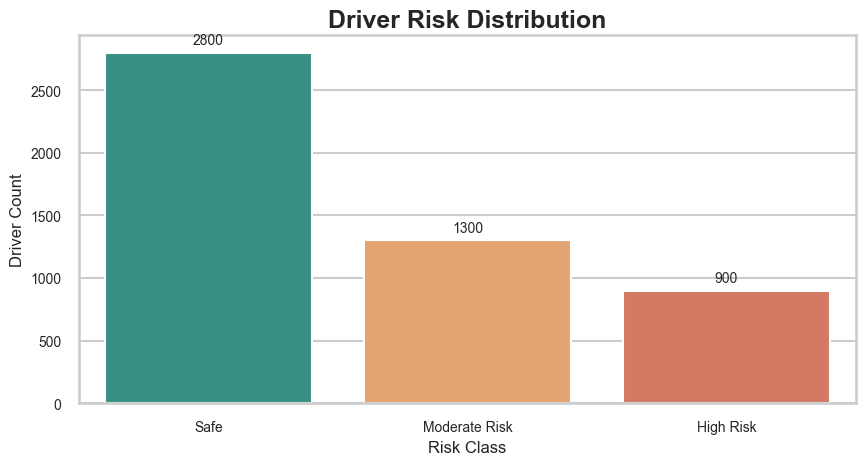

In [13]:
risk_order = ["Safe", "Moderate Risk", "High Risk"]
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=cleaned_df, x="driver_risk", order=risk_order, palette=["#2a9d8f", "#f4a261", "#e76f51"])
ax.set_title("Driver Risk Distribution")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Driver Count")
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height())}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "risk_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


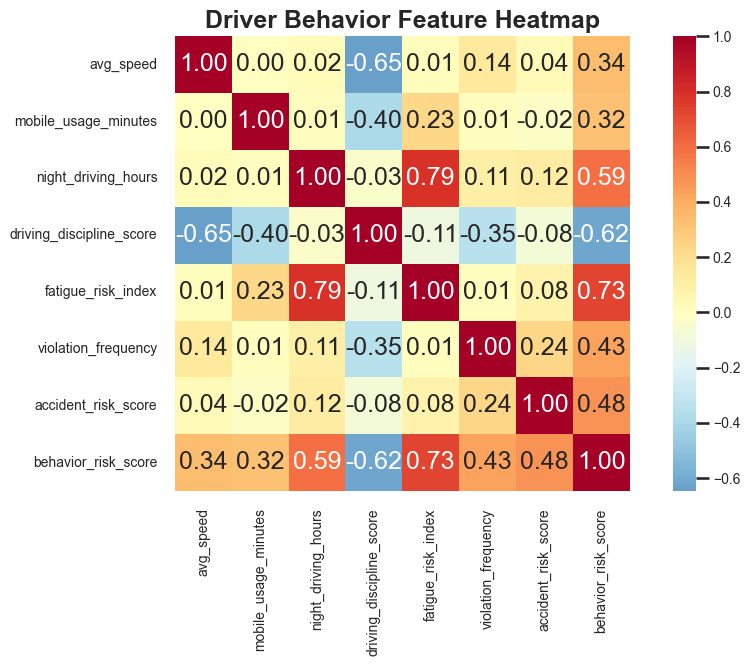

In [14]:
behavior_features = [
    "avg_speed",
    "mobile_usage_minutes",
    "night_driving_hours",
    "driving_discipline_score",
    "fatigue_risk_index",
    "violation_frequency",
    "accident_risk_score",
    "behavior_risk_score",
]

plt.figure(figsize=(10, 7))
corr_matrix = cleaned_df[behavior_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True)
plt.title("Driver Behavior Feature Heatmap")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "driver_behavior_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=cleaned_df, x="driver_risk", y="avg_speed", order=risk_order, palette=["#2a9d8f", "#f4a261", "#e76f51"])
ax.set_title("Average Speed by Risk Class")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Average Speed")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "speed_analysis.png", dpi=180, bbox_inches="tight")
plt.show()
